In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import load_sample_images

dataset=load_sample_images()
Img=dataset.images[1]
Img.shape

(427, 640, 3)

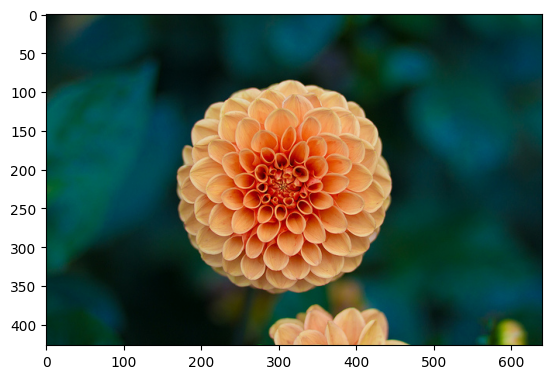

In [4]:
img=Img/255
plt.imshow(img)
plt.show()

In [5]:
x=img.reshape(-1,3)
x.shape

(273280, 3)

In [6]:
from sklearn.cluster import KMeans

kmeans=KMeans(n_clusters=2,random_state=1).fit(x)

In [7]:
kmeans.cluster_centers_

array([[0.0252104 , 0.2120823 , 0.19545371],
       [0.82540994, 0.53242427, 0.31307987]])

In [8]:
kmeans.labels_

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

In [10]:
seg_img=kmeans.cluster_centers_[kmeans.labels_]
seg_img.shape

(273280, 3)

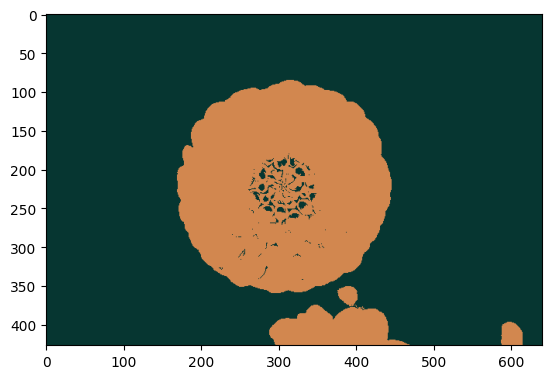

In [11]:
seg_img=seg_img.reshape(img.shape)
plt.imshow(seg_img)
plt.show()

In [12]:
from sklearn.datasets import load_digits

x,y=load_digits(return_X_y=True)
x.shape,y.shape

((1797, 64), (1797,))

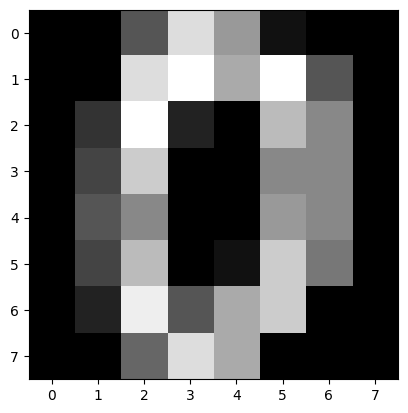

In [13]:
i=0
xi=x[i].reshape(8,8)
plt.imshow(xi,cmap='gray')
plt.show()

In [14]:
y[i]

np.int64(0)

In [15]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=1)

In [16]:
from sklearn.linear_model import LogisticRegression

log_reg=LogisticRegression(multi_class='ovr',max_iter=5000,random_state=1)
log_reg.fit(x_train,y_train)
log_reg.score(x_test,y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


0.9688888888888889

In [17]:
kmeans=KMeans(n_clusters=10,random_state=1)
x_train_dist=kmeans.fit_transform(x_train,y_train)
x_train_dist.shape

(1347, 10)

In [18]:
log_reg=LogisticRegression(multi_class='ovr',max_iter=5000,random_state=1)
log_reg.fit(x_train_dist,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=5000, multi_class='ovr', random_state=1)

In [19]:
x_test_list=kmeans.transform(x_test)
log_reg.score(x_test_list,y_test)

0.9288888888888889

In [20]:
from sklearn.pipeline import Pipeline

pip=Pipeline([
    ('kmeans',KMeans(n_clusters=40,random_state=1)),
    ('log_reg',LogisticRegression(multi_class='ovr',max_iter=5000,random_state=1))
])
pip.fit(x_train,y_train)
pip.score(x_test,y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


0.9777777777777777

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid=dict(kmeans__n_clusters=np.linspace(20,100,5).astype(int))
grid_clf=GridSearchCV(pip,param_grid,cv=3,verbose=2)
grid_clf.fit(x_train,y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


[CV] END ..............................kmeans__n_clusters=20; total time=   6.5s


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


[CV] END ..............................kmeans__n_clusters=20; total time=   2.8s


...

[CV] END .............................kmeans__n_clusters=100; total time=   8.1s


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


[CV] END .............................kmeans__n_clusters=100; total time=   6.4s


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('kmeans',
                                        KMeans(n_clusters=40, random_state=1)),
                                       ('log_reg',
                                        LogisticRegression(max_iter=5000,
                                                           multi_class='ovr',
                                                           random_state=1))]),
             param_grid={'kmeans__n_clusters': array([ 20,  40,  60,  80, 100])},
             verbose=2)

In [25]:
grid_clf.best_params_

{'kmeans__n_clusters': np.int64(60)}

In [26]:
rlt=grid_clf.cv_results_
for mean_score,params in zip(grid_clf.cv_results_['mean_test_score'],rlt['params']):
    print(mean_score,params)

0.9458054936896808 {'kmeans__n_clusters': np.int64(20)}
0.96362286562732 {'kmeans__n_clusters': np.int64(40)}
0.9651076466221232 {'kmeans__n_clusters': np.int64(60)}
0.9651076466221232 {'kmeans__n_clusters': np.int64(80)}
0.9621380846325168 {'kmeans__n_clusters': np.int64(100)}


In [27]:
grid_clf.best_estimator_.score(x_test,y_test)

0.9822222222222222

In [28]:
k=50

kmeans=KMeans(n_clusters=k,random_state=1)
x_dist=kmeans.fit_transform(x_train)

In [29]:
rep_ind=np.argmin(x_dist,axis=0)
x_train_rep=x_train[rep_ind]

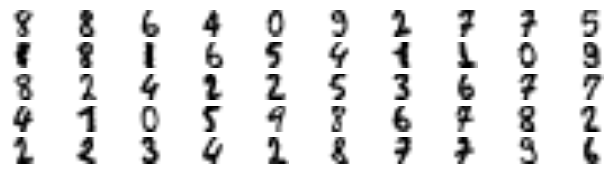

In [30]:
plt.figure(figsize=(8,2))
for idx,xi in enumerate(x_train_rep):
    plt.subplot(k//10,10,idx+1)
    plt.imshow(xi.reshape(8,8),cmap='binary',interpolation='bilinear')
    plt.axis('off')

plt.show()

In [31]:
y_rep=np.array([
    9,2,0,4,7,5,1,6,3,1,
    2,3,1,6,8,5,2,9,4,4,
    7,4,8,3,6,9,5,7,7,2,
    2,1,4,7,3,0,9,4,7,3,
    1,1,3,1,0,2,8,9,8,4
])

In [32]:
y_train_propagated=np.empty(len(x_train),dtype=np.int32)
for i in range(k):
  y_train_propagated[kmeans.labels_==i]=y_rep[i]

In [34]:
x_train.shape,y_train_propagated.shape

((1347, 64), (1347,))

In [35]:
log_reg=LogisticRegression(multi_class='ovr',max_iter=5000,random_state=1)
log_reg.fit(x_train,y_train_propagated)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=5000, multi_class='ovr', random_state=1)

In [36]:
log_reg.score(x_test,y_test)

0.09777777777777778